# Multi-Plane Segmentation Visualization with Bounding Boxes

Visualize segmentation masks and their extracted 3D bounding boxes from three orthogonal planes.

In [ ]:
# Import segmentation processing utilities
import nibabel as nib
from datasets.preprocessing import mask_to_boxes_3d
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load a sample segmentation file
SEGMENTATION_PATH = 'path/to/segmentations/45406.nii'
IMAGES_DIR = 'path/to/train_images/43492/45406'

print(f"Loading segmentation from {SEGMENTATION_PATH}...")
seg_nib = nib.load(SEGMENTATION_PATH)
seg_data = seg_nib.get_fdata()

print(f"Original segmentation shape (H, W, D): {seg_data.shape}")

# Apply same transformations as segmentation_analysis.py:
# 1. Rotate segmentation to match image orientation (same as resize_segmentation)
seg_data = np.rot90(seg_data, k=1)

# 2. Flip depth dimension (same as frame_index = num_frames - 1 - position_in_range)
seg_data = seg_data[:, :, ::-1]

# 3. Transpose from (H, W, D) to (D, H, W) to match volume_images format
seg_data = np.transpose(seg_data, (2, 0, 1))

print(f"Transformed segmentation shape (D, H, W): {seg_data.shape}")
print(f"Unique labels: {np.unique(seg_data)}")

# Extract 3D bounding boxes using data pipeline function
# Note: mask_to_boxes_3d expects (D, H, W) or (H, W, D) format - check its implementation
boxes_data = mask_to_boxes_3d(seg_data, min_volume=500)

print(f"\nExtracted {len(boxes_data)} bounding boxes:")
for i, box_info in enumerate(boxes_data):
    print(f"  Box {i+1}: Label {box_info['label']}, Box (normalized): {box_info['box']}")

Loading segmentation from /home/woody/iwi5/iwi5378h/rsna2023/segmentations/45406.nii...
Original segmentation shape (H, W, D): (512, 512, 113)
Transformed segmentation shape (D, H, W): (113, 512, 512)
Unique labels: [0. 1. 2. 3. 4. 5.]

Extracted 5 bounding boxes:
  Box 1: Label 1, Box (normalized): [0.42285156 0.48046875 0.27876106 0.37890625 0.34179688 0.24778761]
  Box 2: Label 2, Box (normalized): [0.67089844 0.58691406 0.23451327 0.23046875 0.22265625 0.12389381]
  Box 3: Label 3, Box (normalized): [0.64941406 0.515625   0.43362832 0.12890625 0.13867188 0.20353982]
  Box 4: Label 4, Box (normalized): [0.38476562 0.57421875 0.40265487 0.15039062 0.12695312 0.17699115]
  Box 5: Label 5, Box (normalized): [0.51171875 0.49023438 0.43362832 0.50585938 0.36132812 0.87610619]


In [2]:
# Load images (DICOM preferred, JPEG fallback)
from PIL import Image
import os

try:
    import pydicom
    PYDICOM_AVAILABLE = True
except ImportError:
    PYDICOM_AVAILABLE = False
    print("Warning: pydicom not installed. DCM support disabled.")


def load_volume_from_directory(images_dir: str) -> np.ndarray:
    """
    Load image volume from directory. Prioritizes DICOM, falls back to JPEG.
    
    Args:
        images_dir: Directory containing image files
        
    Returns:
        volume: Image volume (D, H, W, C) for visualization
    """
    # Try DICOM first
    dcm_files = sorted(
        [f for f in os.listdir(images_dir) if f.endswith('.dcm')],
        key=lambda f: int(os.path.splitext(f)[0])
    )
    
    if dcm_files and PYDICOM_AVAILABLE:
        print(f"Loading {len(dcm_files)} DICOM files...")
        slices = []
        for dcm_file in dcm_files:
            ds = pydicom.dcmread(os.path.join(images_dir, dcm_file))
            pixel_array = ds.pixel_array.astype(np.float32)
            # Convert to HU if available
            if hasattr(ds, 'RescaleSlope') and hasattr(ds, 'RescaleIntercept'):
                pixel_array = pixel_array * float(ds.RescaleSlope) + float(ds.RescaleIntercept)
            slices.append(pixel_array)
        
        volume = np.stack(slices, axis=0)
        # Normalize HU to [0, 255] for visualization (abdominal window)
        volume = np.clip(volume, -200, 300)
        volume = ((volume + 200) / 500 * 255).astype(np.uint8)
        # Convert to RGB
        volume = np.stack([volume] * 3, axis=-1)
        print(f"Loaded DICOM volume: {volume.shape}")
        return volume
    
    # Fallback to JPEG
    jpeg_files = sorted(
        [f for f in os.listdir(images_dir) if f.endswith(('.jpeg', '.jpg'))],
        key=lambda f: int(os.path.splitext(f)[0])
    )
    
    if jpeg_files:
        print(f"Loading {len(jpeg_files)} JPEG files...")
        images = []
        for jpeg_file in jpeg_files:
            img = np.array(Image.open(os.path.join(images_dir, jpeg_file)))
            if len(img.shape) == 2:
                img = np.stack([img] * 3, axis=-1)
            images.append(img)
        volume = np.stack(images, axis=0)
        print(f"Loaded JPEG volume: {volume.shape}")
        return volume
    
    raise FileNotFoundError(f"No DICOM or JPEG files found in {images_dir}")


# Load volume
volume_images = load_volume_from_directory(IMAGES_DIR)
print(f"Volume shape: {volume_images.shape}")

Loading 113 DICOM files...
Loaded DICOM volume: (113, 512, 512, 3)
Volume shape: (113, 512, 512, 3)


In [3]:
def visualize_slice_with_segmentation_and_bbox(volume, seg_mask, boxes_data, 
                                                 slice_idx, axis='axial'):
    """
    Visualize a 2D slice with segmentation overlay and bounding boxes.
    
    Args:
        volume: 3D image volume (D, H, W, C)
        seg_mask: 3D segmentation mask (D, H, W)
        boxes_data: List of box dicts from mask_to_boxes_3d
        slice_idx: Index of slice to visualize
        axis: 'axial', 'sagittal', or 'coronal'
    
    Returns:
        2D image with overlays
    """
    D, H, W = seg_mask.shape
    
    # Extract 2D slice based on axis
    if axis == 'axial' or axis == 'transverse':
        # Axial/transverse: view from top (slice along D)
        image_slice = volume[slice_idx, :, :, :]
        seg_slice = seg_mask[slice_idx, :, :]
        # For bbox projection: check if cz overlaps with slice
        def project_box(box):
            cx, cy, cz, w, h, d = box
            # Denormalize
            cz_px = cz * D
            d_px = d * D
            cy_px = cy * H
            h_px = h * H
            cx_px = cx * W
            w_px = w * W
            # Check if box intersects this slice
            if abs(cz_px - slice_idx) < d_px / 2:
                # Return 2D bbox: x_min, y_min, x_max, y_max
                return [
                    cx_px - w_px/2, cy_px - h_px/2,
                    cx_px + w_px/2, cy_px + h_px/2
                ]
            return None
    elif axis == 'sagittal':
        # Sagittal: view from side (slice along W)
        image_slice = volume[:, :, slice_idx, :]
        seg_slice = seg_mask[:, :, slice_idx]
        def project_box(box):
            cx, cy, cz, w, h, d = box
            cx_px = cx * W
            w_px = w * W
            cy_px = cy * H
            h_px = h * H
            cz_px = cz * D
            d_px = d * D
            if abs(cx_px - slice_idx) < w_px / 2:
                return [
                    cy_px - h_px/2, cz_px - d_px/2,
                    cy_px + h_px/2, cz_px + d_px/2
                ]
            return None
    elif axis == 'coronal':
        # Coronal: view from front (slice along H)
        image_slice = volume[:, slice_idx, :, :]
        seg_slice = seg_mask[:, slice_idx, :]
        def project_box(box):
            cx, cy, cz, w, h, d = box
            cy_px = cy * H
            h_px = h * H
            cx_px = cx * W
            w_px = w * W
            cz_px = cz * D
            d_px = d * D
            if abs(cy_px - slice_idx) < h_px / 2:
                return [
                    cx_px - w_px/2, cz_px - d_px/2,
                    cx_px + w_px/2, cz_px + d_px/2
                ]
            return None
    
    # Create overlay
    overlay = image_slice.copy().astype(float)
    
    # Define colors for different labels
    label_colors = {
        1: [255, 0, 0],    # Red
        2: [0, 255, 0],    # Green
        3: [0, 0, 255],    # Blue
        4: [255, 255, 0],  # Yellow
        5: [255, 0, 255],  # Magenta
    }
    
    # Resize segmentation to match image if needed
    if seg_slice.shape != image_slice.shape[:2]:
        seg_slice = cv2.resize(seg_slice, (image_slice.shape[1], image_slice.shape[0]), 
                               interpolation=cv2.INTER_NEAREST)
    
    # Overlay segmentation masks with transparency
    for label in range(1, 6):
        mask_bool = seg_slice == label
        if np.any(mask_bool):
            color = np.array(label_colors.get(label, [128, 128, 128]))
            overlay[mask_bool] = 0.6 * overlay[mask_bool] + 0.4 * color
    
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    
    # Draw bounding boxes
    for box_info in boxes_data:
        box_2d = project_box(box_info['box'])
        if box_2d is not None:
            x1, y1, x2, y2 = [int(coord) for coord in box_2d]
            label = box_info['label']
            color = label_colors.get(label, [255, 255, 255])
            cv2.rectangle(overlay, (x1, y1), (x2, y2), color, 2)
            # Add label text
            cv2.putText(overlay, f'L{label}', (x1, y1-5), 
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    
    return overlay

Generating Transverse (Axial) Plane Visualization...
Volume shape: (113, 512, 512), Segmentation shape: (113, 512, 512)


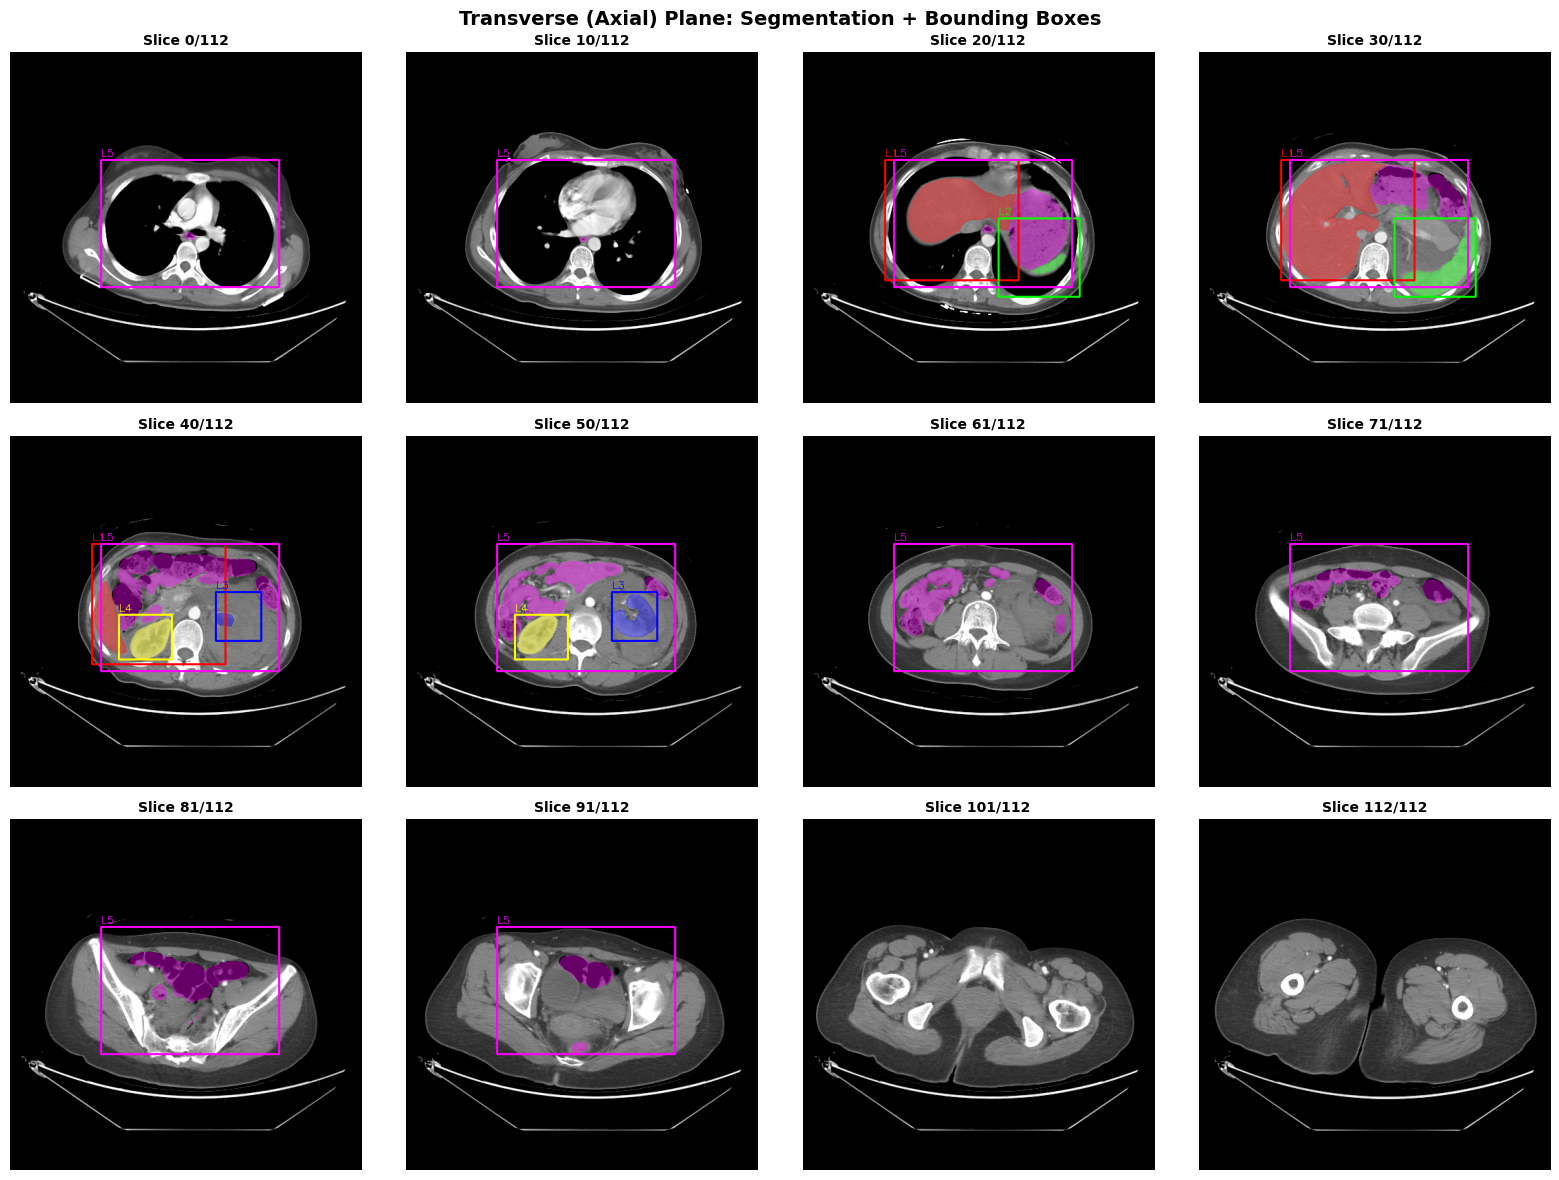

✓ Transverse plane visualization complete!


In [4]:
# Transverse (Axial) Plane Visualization
print("Generating Transverse (Axial) Plane Visualization...")

# Use volume_images dimensions (not seg_data) since they may differ
D_vol, H_vol, W_vol = volume_images.shape[:3]
D_seg, H_seg, W_seg = seg_data.shape
num_samples = 12

print(f"Volume shape: {volume_images.shape[:3]}, Segmentation shape: {seg_data.shape}")

# Resize seg_data to match volume_images if needed
if (D_seg, H_seg, W_seg) != (D_vol, H_vol, W_vol):
    print(f"Resizing segmentation from {seg_data.shape} to {(D_vol, H_vol, W_vol)}...")
    from scipy.ndimage import zoom
    zoom_factors = (D_vol / D_seg, H_vol / H_seg, W_vol / W_seg)
    seg_data_resized = zoom(seg_data, zoom_factors, order=0)  # order=0 for nearest neighbor
    print(f"Resized segmentation shape: {seg_data_resized.shape}")
else:
    seg_data_resized = seg_data

# Uniformly sample slice indices based on volume dimensions
slice_indices = np.linspace(0, D_vol-1, num_samples, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, slice_idx in enumerate(slice_indices):
    ax = axes[idx]
    
    # Get visualization using resized segmentation
    vis_image = visualize_slice_with_segmentation_and_bbox(
        volume_images, seg_data_resized, boxes_data, slice_idx, axis='axial'
    )
    
    ax.imshow(vis_image)
    ax.set_title(f'Slice {slice_idx}/{D_vol-1}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Transverse (Axial) Plane: Segmentation + Bounding Boxes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Transverse plane visualization complete!")

Generating Sagittal Plane Visualization...


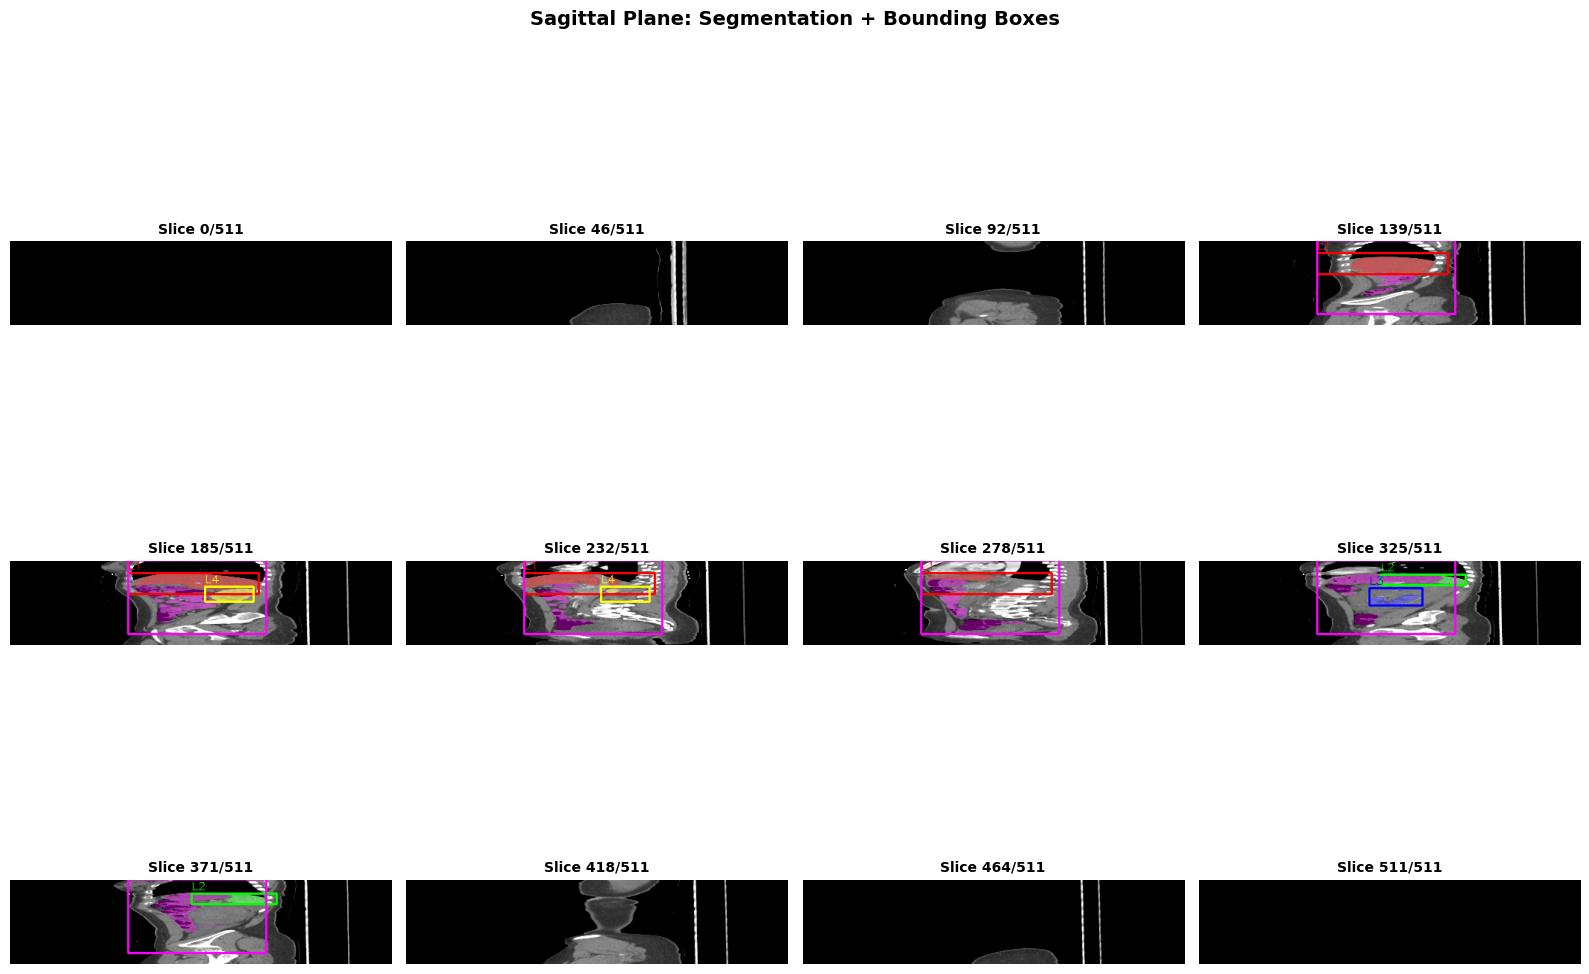

✓ Sagittal plane visualization complete!


In [5]:
# Sagittal Plane Visualization
print("Generating Sagittal Plane Visualization...")

# Uniformly sample slice indices along W dimension (using volume dimensions)
slice_indices = np.linspace(0, W_vol-1, num_samples, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, slice_idx in enumerate(slice_indices):
    ax = axes[idx]
    
    # Get visualization using resized segmentation
    vis_image = visualize_slice_with_segmentation_and_bbox(
        volume_images, seg_data_resized, boxes_data, slice_idx, axis='sagittal'
    )
    
    ax.imshow(vis_image)
    ax.set_title(f'Slice {slice_idx}/{W_vol-1}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sagittal Plane: Segmentation + Bounding Boxes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Sagittal plane visualization complete!")

Generating Coronal Plane Visualization...


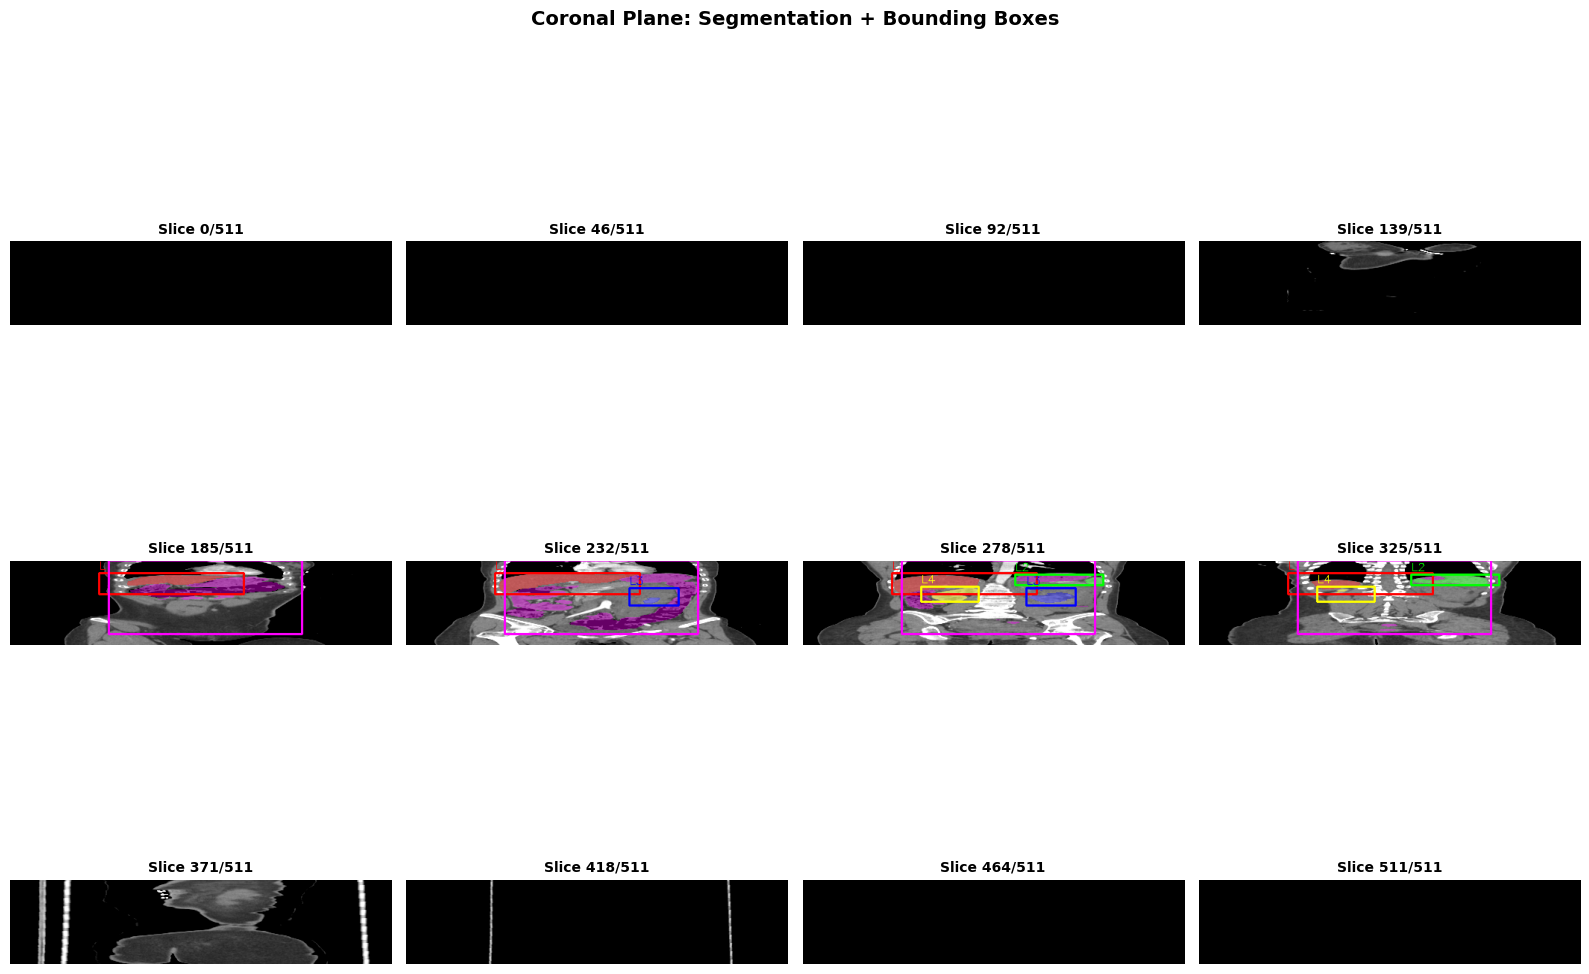

✓ Coronal plane visualization complete!


In [6]:
# Coronal Plane Visualization
print("Generating Coronal Plane Visualization...")

# Uniformly sample slice indices along H dimension (using volume dimensions)
slice_indices = np.linspace(0, H_vol-1, num_samples, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, slice_idx in enumerate(slice_indices):
    ax = axes[idx]
    
    # Get visualization using resized segmentation
    vis_image = visualize_slice_with_segmentation_and_bbox(
        volume_images, seg_data_resized, boxes_data, slice_idx, axis='coronal'
    )
    
    ax.imshow(vis_image)
    ax.set_title(f'Slice {slice_idx}/{H_vol-1}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Coronal Plane: Segmentation + Bounding Boxes', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Coronal plane visualization complete!")